# Assignment 2: Transfer Learning Across Two Datasets

**Name:** *Mark Hanafin
*

**Prerequisite:** Transfer Learning lecture (frozen feature extraction)

This assignment uses frozen transfer learning, exactly what was covered in lecture: load a pretrained base, freeze it, add a new head, train only that. You'll do this twice, on two different datasets, and compare the results.

Data loading is provided for you below. Everything after that, building the model, training, evaluating, and reflecting, is yours to write, following the general instructions in each section.

**Submission:** GitHub repo URL and this notebook's URL on Canvas.

## Setup — Imports

In [5]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

---
# Part 1: Fire/Smoke Detection

## 1A — Load the Data

In [9]:
!pip install legacy-cgi --quiet
!pip install opendatasets --quiet

import opendatasets as od
od.download("https://www.kaggle.com/datasets/phylake1337/fire-dataset")

for root, dirs, files in os.walk("fire-dataset"):
    print(root, "->", dirs[:5], f"({len(files)} files)")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: markhanafin
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/phylake1337/fire-dataset


100%|██████████| 387M/387M [00:01<00:00, 276MB/s]



fire-dataset -> ['fire_dataset'] (0 files)
fire-dataset/fire_dataset -> ['fire_images', 'non_fire_images'] (0 files)
fire-dataset/fire_dataset/fire_images -> [] (755 files)
fire-dataset/fire_dataset/non_fire_images -> [] (244 files)


In [10]:
data_dir_fire = "fire-dataset/fire_dataset"

img_size = (224, 224)
batch_size = 32

train_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_fire = tf.data.experimental.cardinality(val_test_raw_fire)
test_raw_fire = val_test_raw_fire.take(val_test_batches_fire // 2)
val_raw_fire = val_test_raw_fire.skip(val_test_batches_fire // 2)

class_names_fire = train_raw_fire.class_names
print("Class names:", class_names_fire)

Found 999 files belonging to 2 classes.
Using 700 files for training.
Found 999 files belonging to 2 classes.
Using 299 files for validation.
Class names: ['fire_images', 'non_fire_images']


## 1B — Inspect the Data

Before doing anything else, take a real look at what you loaded. How many images does each class have? Is there anything about the data itself that might affect how you should split it, or how you should interpret your model's results later?

Write whatever code you need to answer this for yourself.

Fire images:     755 (75.6%)
Non-fire images: 244 (24.4%)

Training split counts:
  fire_images: 538
  non_fire_images: 162


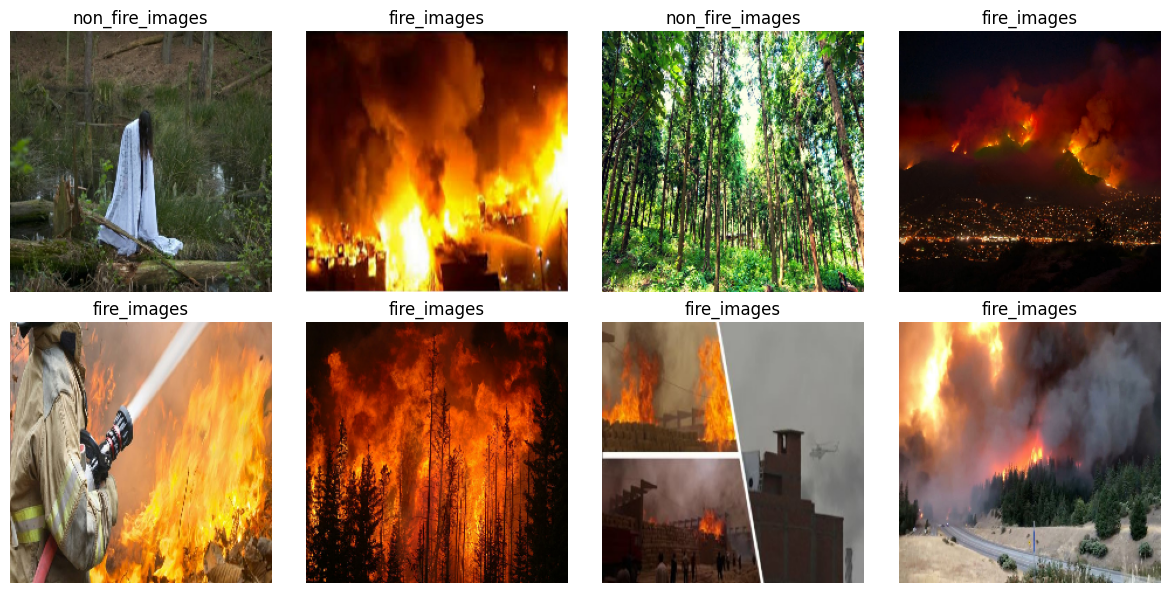

In [4]:
# Your exploration here
# Your exploration here
fire_count = len(os.listdir(os.path.join(data_dir_fire, "fire_images")))
nonfire_count = len(os.listdir(os.path.join(data_dir_fire, "non_fire_images")))
total = fire_count + nonfire_count
print(f"Fire images:     {fire_count} ({fire_count / total:.1%})")
print(f"Non-fire images: {nonfire_count} ({nonfire_count / total:.1%})")

train_labels = np.concatenate([y.numpy() for _, y in train_raw_fire])
print("\nTraining split counts:")
for i, name in enumerate(class_names_fire):
    print(f"  {name}: {np.sum(train_labels == i)}")

plt.figure(figsize=(12, 6))
for images, labels in train_raw_fire.take(1):
    for i in range(8):
        plt.subplot(2, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names_fire[labels[i]])
        plt.axis("off")
plt.tight_layout()
plt.show()


*What did you notice about this dataset? Does it change how you'll approach the next steps?*

The dataset is imbalanced: 755 fire images (75.6%) and only 244 non-fire images (24.4%), and the training split keeps about the same ratio, with 538 fire and 162 non-fire. Because of this, accuracy alone can be misleading, since a model that always guessed "fire" would already score around 76%. The dataset is also small, only 999 images, so the test set ends up with roughly 150 images and only about 35 non-fire ones. Because of the imbalance, I'll judge the model using the confusion matrix and not just accuracy,


## 1C — Build a Frozen Transfer Learning Model

Using MobileNetV2 as your pretrained base:
- Freeze the base model entirely
- Add a new output layer appropriate for this task (think about how many classes you're predicting, and what that means for your output layer's size, activation, and loss function)
- Remember the pattern from lecture for how the base model should be called

Preprocess your data (`train_raw_fire`, `val_raw_fire`, `test_raw_fire`) using MobileNetV2's expected preprocessing before building your model.

In [13]:
# Preprocess the data here
def prep_fire(x, y):
    return preprocess_input(x), tf.cast(1 - y, tf.float32)

AUTOTUNE = tf.data.AUTOTUNE
train_fire = train_raw_fire.map(prep_fire).prefetch(AUTOTUNE)
val_fire = val_raw_fire.map(prep_fire).prefetch(AUTOTUNE)
test_fire = test_raw_fire.map(prep_fire).prefetch(AUTOTUNE)


In [6]:
# Build your model here
base_fire = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights="imagenet")
base_fire.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_fire(inputs, training=False)
x = GlobalAveragePooling2D()(x)
outputs = Dense(1, activation="sigmoid")(x)

model_fire = Model(inputs, outputs)



9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
# Compile your model here
model_fire.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
model_fire.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 1D — Train and Evaluate

In [8]:
# Train your model here
history_fire = model_fire.fit(
    train_fire,
    validation_data=val_fire,
    epochs=5
)



Epoch 1/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 104s 4s/step - accuracy: 0.7400 - loss: 0.4922 - val_accuracy: 0.8489 - val_loss: 0.3145
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 101s 3s/step - accuracy: 0.9471 - loss: 0.1887 - val_accuracy: 0.9496 - val_loss: 0.1691
Epoch 3/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - accuracy: 0.9657 - loss: 0.1279 - val_accuracy: 0.9712 - val_loss: 0.1322
Epoch 4/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.9714 - loss: 0.1028 - val_accuracy: 0.9784 - val_loss: 0.1007
Epoch 5/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.9771 - loss: 0.0882 - val_accuracy: 0.9856 - val_loss: 0.0855


In [9]:
# Report validation and test accuracy here
val_loss_fire, val_acc_fire = model_fire.evaluate(val_fire, verbose=0)
test_loss_fire, test_acc_fire = model_fire.evaluate(test_fire, verbose=0)
print(f"Validation Accuracy: {val_acc_fire * 100:.2f}%")
print(f"Test Accuracy:       {test_acc_fire * 100:.2f}%")



Validation Accuracy: 97.84%
Test Accuracy:       97.50%


## 1E — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** In this context, is a false negative (missing a real fire) or a false positive (a false alarm) more costly? How might that change the decision threshold you'd actually use in practice, rather than the default 0.5?

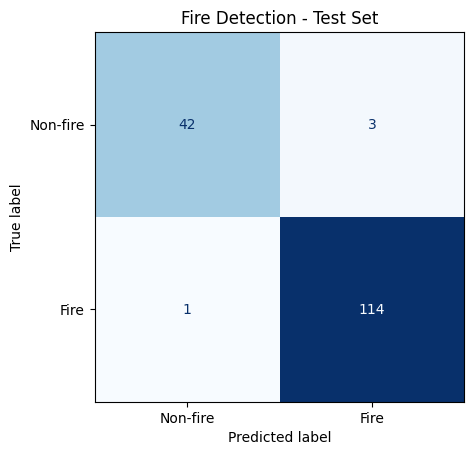

In [10]:
# Build your confusion matrix here
y_true_fire, y_prob_fire = [], []
for x, y in test_fire:
    y_true_fire.extend(y.numpy())
    y_prob_fire.extend(model_fire.predict(x, verbose=0).flatten())

y_true_fire = np.array(y_true_fire).astype(int)
y_pred_fire = (np.array(y_prob_fire) > 0.5).astype(int)

cm_fire = confusion_matrix(y_true_fire, y_pred_fire)
ConfusionMatrixDisplay(cm_fire, display_labels=["Non-fire", "Fire"]).plot(cmap="Blues", colorbar=False)
plt.title("Fire Detection - Test Set")
plt.show()



*Your answer:*
A false negative is more costly here. Missing a real fire would slow response times and allow it to spread and cause more damage, while a false alarm just means someone checks and finds nothing. Our model made 1 false negative (a real fire predicted as non-fire) and 3 false positives (non-fire images flagged as fire) out of 160 test images. In practice, we would lower the decision threshold below 0.5, for example to 0.3, so the model calls something "fire" even when it's less confident.



---
# Part 2: Satellite Land-Use Classification (EuroSAT)

## 2A — Load the Data

In [6]:
!wget "https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1" -O EuroSAT_RGB.zip
!unzip -qo EuroSAT_RGB.zip -d eurosat_data

data_dir_sat = "eurosat_data/EuroSAT_RGB"
print(os.listdir(data_dir_sat))

--2026-10-05 15:00:19--  https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1
Resolving zenodo.org (zenodo.org)... 137.138.52.235, 188.185.48.75, 188.184.98.114, ...
Connecting to zenodo.org (zenodo.org)|137.138.52.235|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 94658721 (90M) [application/octet-stream]
Saving to: ‘EuroSAT_RGB.zip’

EuroSAT_RGB.zip     100%[===================>]  90.27M  2.55MB/s    in 47s     

2026-10-05 15:01:07 (1.92 MB/s) - ‘EuroSAT_RGB.zip’ saved [94658721/94658721]

['SeaLake', 'HerbaceousVegetation', 'Forest', 'PermanentCrop', 'AnnualCrop', 'Industrial', 'Residential', 'Pasture', 'River', 'Highway']


In [11]:
train_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_sat = tf.data.experimental.cardinality(val_test_raw_sat)
test_raw_sat = val_test_raw_sat.take(val_test_batches_sat // 2)
val_raw_sat = val_test_raw_sat.skip(val_test_batches_sat // 2)

class_names_sat = train_raw_sat.class_names
print("Class names:", class_names_sat)

Found 27000 files belonging to 10 classes.
Using 18900 files for training.
Found 27000 files belonging to 10 classes.
Using 8100 files for validation.
Class names: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## 2B — Build a Frozen Transfer Learning Model

Same overall pattern as Part 1, but look closely at what's different about this task before you build your output layer, activation, and loss function.

Preprocess `train_raw_sat`, `val_raw_sat`, and `test_raw_sat` first.

In [14]:
# Preprocess the data here
def prep_sat(x, y):
    return preprocess_input(x), y

train_sat = train_raw_sat.map(prep_sat).prefetch(AUTOTUNE)
val_sat = val_raw_sat.map(prep_sat).prefetch(AUTOTUNE)
test_sat = test_raw_sat.map(prep_sat).prefetch(AUTOTUNE)



In [15]:
# Build your model here
base_sat = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights="imagenet")
base_sat.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_sat(inputs, training=False)
x = GlobalAveragePooling2D()(x)
outputs = Dense(10, activation="softmax")(x)

model_sat = Model(inputs, outputs)



9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [16]:
# Compile your model here
model_sat.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model_sat.summary()



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 2C — Train and Evaluate

In [17]:
# Train your model here
history_sat = model_sat.fit(
    train_sat,
    validation_data=val_sat,
    epochs=5
)



Epoch 1/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 58s 79ms/step - accuracy: 0.8758 - loss: 0.3728 - val_accuracy: 0.9329 - val_loss: 0.2149
Epoch 2/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 52s 41ms/step - accuracy: 0.9333 - loss: 0.1968 - val_accuracy: 0.9383 - val_loss: 0.1888
Epoch 3/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 24s 40ms/step - accuracy: 0.9468 - loss: 0.1607 - val_accuracy: 0.9388 - val_loss: 0.1846
Epoch 4/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 27s 45ms/step - accuracy: 0.9524 - loss: 0.1397 - val_accuracy: 0.9403 - val_loss: 0.1810
Epoch 5/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 40s 44ms/step - accuracy: 0.9603 - loss: 0.1228 - val_accuracy: 0.9428 - val_loss: 0.1764


In [18]:
# Report validation and test accuracy here
val_loss_sat, val_acc_sat = model_sat.evaluate(val_sat, verbose=0)
test_loss_sat, test_acc_sat = model_sat.evaluate(test_sat, verbose=0)
print(f"Validation Accuracy: {val_acc_sat * 100:.2f}%")
print(f"Test Accuracy:       {test_acc_sat * 100:.2f}%")



Validation Accuracy: 94.20%
Test Accuracy:       93.82%


## 2D — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** Which land-use classes get confused most often? Does that make visual sense to you?

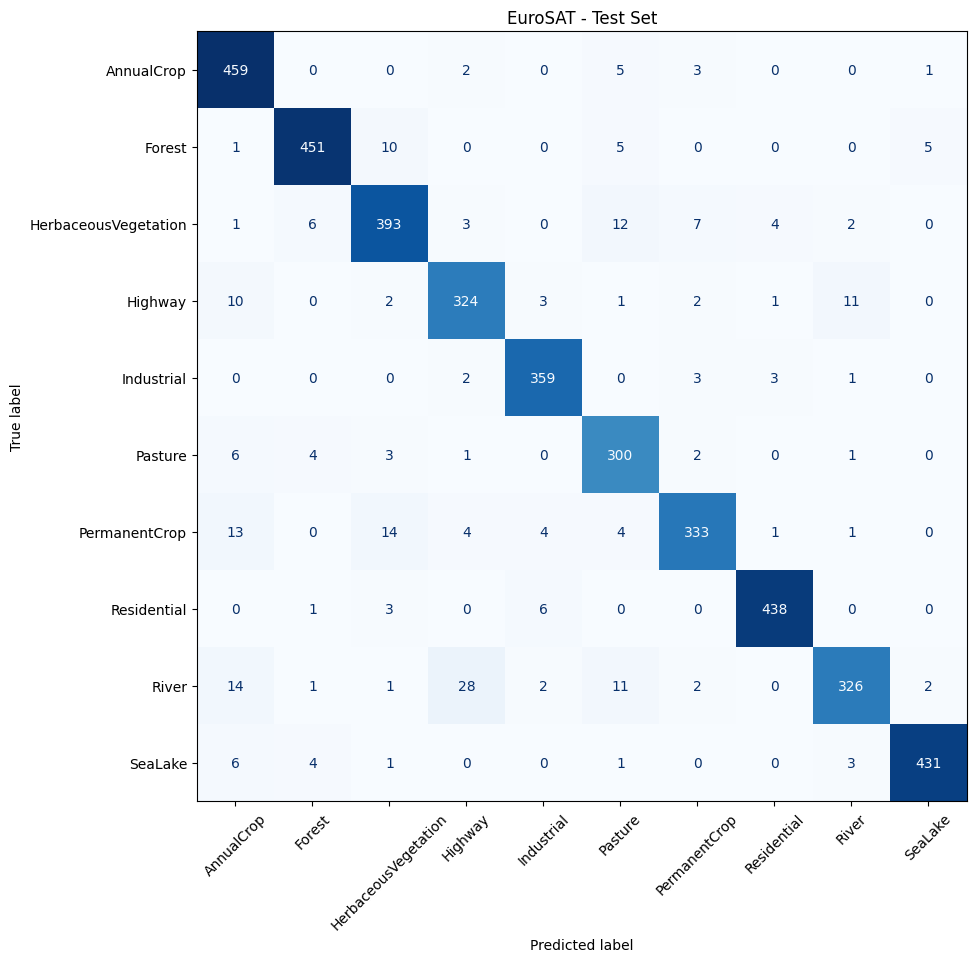

In [19]:
# Build your confusion matrix here
y_true_sat, y_pred_sat = [], []
for x, y in test_sat:
    y_true_sat.extend(y.numpy())
    y_pred_sat.extend(np.argmax(model_sat.predict(x, verbose=0), axis=1))

cm_sat = confusion_matrix(y_true_sat, y_pred_sat)
fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay(cm_sat, display_labels=class_names_sat).plot(
    ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
plt.title("EuroSAT - Test Set")
plt.show()



*Your answer:*
The most common confusion was between River and Highway, where 28 rivers were predicted as highways, and 11 highways were predicted as rivers. River was the weakest class overall, with only 326 of 387 correct. This makes visual sense, because from directly overhead both rivers and highways look similar, and at low resolution their color and texture can look similar. The other main confusions were among the farmland and vegetation classes, like permanent crops predicted as herbaceous vegetation (14) or annual crop (13), and herbaceous vegetation predicted as pasture (12). These also make sense, because from above they are all green or brown fields with similar textures, and the differences between them, like crop type or how the land is used, are hard to see in a small satellite image. Classes with a distinct look, like SeaLake, Residential, and Industrial, were almost always correct.



---
# Part 3: Compare the Two Domains

Fill in your own results:

| | Fire/Smoke | EuroSAT |
|---|---|---|
| Validation Accuracy | 97.84% | 94.20% |
| Test Accuracy | 97.50% | 93.82% |

**Answer:**
1. MobileNetV2 was originally trained on ImageNet, ordinary ground-level photos of everyday objects. Which of your two datasets do you think is the closer match to that original training, and which is the bigger mismatch? Use your actual results as evidence.
2. For each dataset, do you think there's room for improvement if you could adjust part of the pretrained model itself, rather than just the new layer on top? Would you expect that to matter more for one dataset than the other? Why?

*Your answers:*
1. Fire/Smoke is the closer match to ImageNet, and EuroSAT is the bigger mismatch. Fire images are ordinary ground-level photos of scenes like forests, buildings, and firefighters, which, according to the given description, lines up with what  MobileNetV2 learned from. EuroSAT images are taken from directly overhead, so things like roads, rivers, and fields look nothing like they would in a normal photo. Our results match this: the frozen model scored 97.84% validation and 97.50% test accuracy on Fire, but only 94.20% validation and 93.82% test accuracy on EuroSAT, even though EuroSAT had far more training images (18,900 vs. 700). The pretrained features worked better on the dataset that looks more like what the model was originally trained on.

2. Both datasets could improve if we unfroze some of the top layers of the pretrained model and trained them with a small learning rate (fine-tuning), but we'd expect it to matter more for EuroSAT. Its images are a bigger mismatch with ImageNet, so adjusting the deeper layers would let the model learn features specific to satellite images, like the difference between a river and a highway seen from above, which were its most common mistakes. EuroSAT also has a large training set, so fine-tuning is less likely to cause overfitting. Fire is already at 97.50% test accuracy, so there's less room to gain. It only has 700 training images, so unfreezing more of the model would increase the risk of overfitting.

---
# Part 4: Reflection

Answer in 4 to 6 sentences:

1. Did anything about the Fire dataset's composition affect how you approached splitting or evaluating it? Explain.
2. What's the actual difference between the output layer, activation, and loss function you used in Part 1 versus Part 2? Why does that difference exist?
3. Based on your results, does a pretrained model's usefulness depend only on how good the model is, or also on how well its original training matches your task? Explain using your own two results as evidence.

*Your answers:*

Yes, the Fire dataset was about 76% fire images, so a model could score high accuracy just by guessing "fire," which is why we relied on the confusion matrix to check for missed fires and false alarms instead of accuracy alone. The random split also left only about 45 non-fire images in the test set, so even a few mistakes would noticeably change the results. In Part 1, we used one output neuron with sigmoid and binary crossentropy because the task is a yes/no question, and sigmoid gives a single probability that the image is fire. In Part 2, we used 10 output neurons with softmax and sparse categorical crossentropy because there are 10 land-use classes, softmax spreads the probability across all of them, and the labels are plain integers isntead of one-hot vectors. A pretrained model's usefulness depends on both, since the same frozen MobileNetV2 scored 97.50% on Fire but 93.82% on EuroSAT. Fire photos are ground-level pictures like the ImageNet images it was trained on, while satellite images show the world from directly overhead, so its learned features fit the fire task better.

---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.